# Fixed Effects Exploration

This notebook explores and visualizes the various **Fixed Effect** configurations used in the synthetic datasets. We load the configurations directly from the Hydra YAML files and plot their realizations.

In [1]:
import math

from src.data.data_layout import CONFIG_FOLDER
from src.plot.publication_plots import plot_fixed_effect_realisation

from src.utils.hydra_config_helpers import instantiate_omega_conf

In [2]:
SYNTHETIC_DATA_FOLDER = CONFIG_FOLDER / "data" / "synthetic"

# Load the fixed effect configurations
STEPS_1D = instantiate_omega_conf(SYNTHETIC_DATA_FOLDER / "fixed_effect" / "steps_1D.yaml")
STEPS_2D = instantiate_omega_conf(SYNTHETIC_DATA_FOLDER / "fixed_effect" / "steps_2D.yaml")

ZERO_1D = instantiate_omega_conf(SYNTHETIC_DATA_FOLDER / "fixed_effect" / "zero_1D.yaml")
ZERO_2D = instantiate_omega_conf(SYNTHETIC_DATA_FOLDER / "fixed_effect" / "zero_2D.yaml")

## 1D Fixed Effects Realizations

Steps 1D:


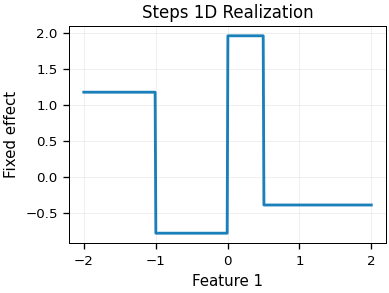

In [3]:
print("Steps 1D:")
plot_fixed_effect_realisation(STEPS_1D, title=f"{STEPS_1D.name} Realization");

# print("Zero 1D:")
# plot_fixed_effect_realisation(ZERO_1D, title=f"{ZERO_1D.name} Realization")

## 2D Fixed Effects Realizations

Steps 2D:


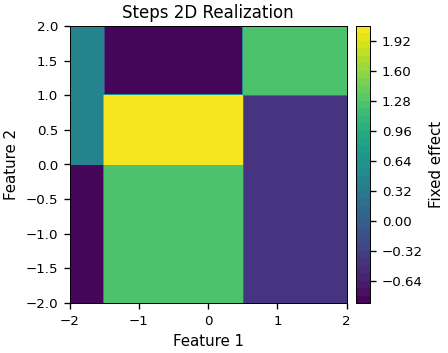

In [4]:
print("Steps 2D:")
plot_fixed_effect_realisation(STEPS_2D, title=f"{STEPS_2D.name} Realization");

# print("Zero 2D:")
# plot_fixed_effect_realisation(ZERO_2D, title=f"{ZERO_2D.name} Realization")

## Multipliers for the fixed effects

We want the variance of the fixed effect to be $1$, which means that we need to multiply our initially defined (unnormalized) function Steps 1D and Steps 2D in ``configs/data/synthetic/fixed_effect`` with the appropriate constant $c$, such that $\text{Var}(c \cdot \bar F(x)) = 1, \quad x \sim \text{Unif}([-2, 2]^d), \, d \in \{1, 2\}$.

As stated in the appendix of the paper, this requires setting $c = \sqrt{\frac{1}{\text{Var}(\bar F(x))}}.$

### Steps 1D

For Steps 1D, the derivation is done in the appendix of the paper.
From $\mathbb{E}[\bar F(x)] = \frac{1}{2}$ and $\mathbb{E}[\bar F(x)^2] = \frac{27}{4}$, it follows that $\operatorname{Var}(\bar F(x)) =  \frac{27}{4} - \left(\frac{1}{2} \right)^2 = \frac{13}{2}$
and therefore $c=\sqrt{\frac{2}{13}} = \frac{1}{\sqrt{6.5}} \approx 0.3922322702763681.$

In [5]:
var_fixed_effect = 6.5
multiplier = 1 / math.sqrt(var_fixed_effect)
multiplier

0.3922322702763681

In [6]:
# Sanity check, since in config file, we need to set the multiplier by hand (i.e. we paste '0.3922322702763681' into steps_1D.yaml)
0.3922322702763681**2 * var_fixed_effect

1.0

## Steps 2D

For calculating the multiplier $c$, we again need to calculate the variance of $F_1(x)$.

This time, we need to be a bit more careful with the $\mathbb{E}[F_1(x)]$ and $\mathbb{E}[F_1(x)^2]$ calculation because there are more different regions.

We get $\mathbb{E}[F_1(x)] = \frac{17}{16}$ and $\mathbb{E}[F_1(x)^2] = \frac{234}{32} = \frac{117}{16}$, which gives
$\text{Var}(F_1(x)) = \frac{234}{32} - \left( \frac{17}{16} \right)^2 = \frac{1583}{256}$.

Hence,
$$
c = \sqrt{\frac{256}{1583}} \approx 0.40214208493397874
$$

In [7]:
var_fixed_effect = 1583 / 256

c = math.sqrt(256 / 1583)
c

0.40214208493397874

In [8]:
# Sanity check, since in config file, we need to set the multiplier by hand (i.e. we paste '0.40214208493397874' into steps_2D.yaml)
0.40214208493397874**2 * var_fixed_effect

0.9999999999999999